# Bank Customer Churn

![Imagem](https://cdn1.expresscomputer.in/wp-content/uploads/2020/02/20120612/New-Project-12-1.jpg)

# One Bank — Previsão de Churn Bancário

**Pipeline completo:** EDA → Feature Engineering → Comparação de Modelos → Otimização → Interpretabilidade → Impacto Financeiro → Simulação de Produção

---
## 1. Contexto e Objetivos
---

### 1.1 Introdução

Este projeto tem como objetivo analisar os dados de clientes de um banco para entender os fatores que levam ao **Churn** (cancelamento/saída do cliente) e construir um modelo preditivo para identificar clientes em risco.

A rotatividade de clientes é um dos maiores drenos de receita em instituições financeiras — conquistar um novo cliente custa de **5 a 25 vezes mais** do que reter um existente.

### 1.2 Objetivos

- Identificar os principais fatores demográficos e financeiros que influenciam a decisão de um cliente deixar o banco
- Analisar correlações entre variáveis como Score de Crédito, localização, saldo e propensão ao churn
- Desenvolver um modelo de Machine Learning capaz de prever a probabilidade de saída
- Traduzir o impacto do modelo em valor financeiro (ROI)

### 1.3 Perguntas de Negócio

1. Quais características dos clientes estão mais associadas à alta probabilidade de churn?
2. Clientes com Score de Crédito mais baixo têm propensão maior a sair?
3. Existe diferença nas taxas de churn entre França, Alemanha e Espanha?
4. Clientes com saldo zerado têm maior probabilidade de sair?
5. Membros ativos têm realmente menor risco de churn?

### 1.4 Métricas de Sucesso do Modelo

Como o custo de perder um cliente é alto, o modelo prioriza:

- **Métrica Principal:** Recall — minimizar Falsos Negativos (clientes que vão sair mas o modelo não detecta)
- **Métrica Secundária:** AUC-ROC — capacidade geral de distinguir entre classes

---
## 2. Carregamento e Inspeção
---

In [1]:
# === IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import shap
import joblib

In [2]:
# === CARREGAMENTO ===
# Opção 1: Google Colab (upload manual)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('Customer-Churn-Records.csv')

# Opção 2: Kaggle
import kagglehub
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
df = pd.read_csv(f"{path}/Customer-Churn-Records.csv")

# Opção 3: Path direto (ajuste conforme seu ambiente)
# df = pd.read_csv('Customer-Churn-Records.csv')
# print(f"Dataset: {df.shape[0]} linhas × {df.shape[1]} colunas")

Using Colab cache for faster access to the 'bank-customer-churn' dataset.


In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [6]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## 2.1 Observações Iniciais

Com base na inspeção inicial dos dados (`df.head()`, `df.info()`, `df.describe()`, `df.isnull().sum()`, `df[col].value_counts()`), podemos destacar alguns pontos importantes:

*   **Tamanho do Dataset:** O DataFrame possui 10.000 linhas e 18 colunas.

*   **Tipos de Dados:**
    *   A maioria das colunas numéricas (`CreditScore`, `Age`, `Tenure`, `NumOfProducts`, `Exited`, `Complain`, `Satisfaction Score`, `Point Earned`) estão corretamente tipadas como `int64`.
    *   `Balance` e `EstimatedSalary` estão como `float64`, o que é apropriado.
    *   Colunas categóricas (`Surname`, `Geography`, `Gender`, `Card Type`) estão como `object`, conforme esperado.
    *   A coluna `Exited` (churn) é binária (0 ou 1) e já está em formato numérico, ideal para modelagem futura.

*   **Valores Faltantes (Missing):** Não há valores faltantes em nenhuma das colunas, o que facilita o pré-processamento.

*   **Valores Negativos ou Anômalos:**
    *   Nenhuma coluna numérica apresentou valores negativos.
    *   `Balance`: Observa-se que 25% dos clientes possuem saldo de 0.00, o que pode indicar clientes inativos ou contas secundárias sem uso para movimentação de dinheiro.
    *   `EstimatedSalary`: O valor mínimo é 11.58, o que não parece problemático.

*   **Distribuição Geográfica:** A maioria dos clientes é da França (50%), seguida por Alemanha (25%) e Espanha (25%), indicando uma distribuição geográfica importante a ser considerada na análise.

*   **Tipo de Cartão:** Os quatro tipos de cartão (`DIAMOND`, `GOLD`, `SILVER`, `PLATINUM`).

*   **Churn (`Exited`):** A média de `Exited` é de aproximadamente 20.38%, indicando que cerca de 20% dos clientes deixaram o banco. Esta será a variável alvo principal.

*   **Colunas de Identificação:** `RowNumber` e `CustomerId` são identificadores únicos e provavelmente não terão relevância direta para a modelagem preditiva, podendo ser removidos ou usados apenas para referências.

---
## 3. Análise Exploratória (EDA)
---

### 3.1 Análise Univariada

In [7]:
# ============================
# PALETA DE CORES PADRÃO
# ============================

cores = {
    "azul":        "#4C72B0",
    "laranja":     "#DD8452",
    "verde":       "#55A868",
    "vermelho":    "#C44E52",
    "roxo":        "#8172B3",
    "marrom":      "#937860",
    "rosa":        "#DA8BC3",
    "cinza":       "#ebebeb",
    "azul_claro":  "#64B5CD",
    "verde_agua":  "#4DB6AC",
    "branco":      "#FFFFFF",
    "cinza_escuro":"#555655",
    "preto":       "#000000"
}

In [8]:
def plot_vertical_bar(
    data,
    title="",
    xlabel="",
    ylabel="",
    palette=None,
    figsize=(10, 6),
    bg_color=None,
    text_color=None,
    grid_color=None,
    order=None,
    label_mode="count"
):
    # ============================
    # CORES PADRÃO DO TEMA
    # ============================

    if bg_color is None:
      bg_color = cores["cinza"]
    if text_color is None:
      text_color = cores["cinza_escuro"]
    if grid_color is None:
      grid_color = cores["cinza_escuro"]
    if palette is None:
      palette = [cores["azul"], cores["laranja"]]

    # Aceitar Series, dict ou DataFrame
    if isinstance(data, dict):
        data = pd.Series(data)
    elif isinstance(data, pd.DataFrame):
        if data.shape[1] != 1:
            raise ValueError("DataFrame deve ter apenas uma coluna")
        data = data.iloc[:, 0]

    # Ordenação opcional
    if order is not None:
        data = data.reindex(order)

    # Cálculo de porcentagens
    percent = (data / data.sum()) * 100

    # Criar figura
    fig, ax = plt.subplots(figsize=figsize, facecolor=bg_color)
    ax.set_facecolor(bg_color)

    # Plot
    sns.barplot(
        x=data.index,
        y=data.values,
        palette=palette,
        ax=ax,
        hue=data.index,  # Adicionado para evitar o FutureWarning
        legend=False     # Adicionado para evitar o FutureWarning e remover a legenda redundante
    )

    # Títulos e labels
    ax.set_title(title, fontsize=18, color=text_color)
    ax.set_xlabel(xlabel, fontsize=12, color=text_color)
    ax.set_ylabel(ylabel, fontsize=12, color=text_color)

    # Remover spines
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    # Grid
    ax.yaxis.grid(color=grid_color, linestyle="--", linewidth=0.5)
    ax.set_axisbelow(True)

    # Rótulos nas barras
    for p, pct in zip(ax.patches, percent):
        height = p.get_height()

        if label_mode == "count":
            label = f"{height:,.0f}"
        elif label_mode == "percent":
            label = f"{pct:.1f}%"
        elif label_mode == "both":
            label = f"{height:,.0f} ({pct:.1f}%)"
        else:
            raise ValueError("label_mode deve ser 'count', 'percent' ou 'both'")

        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=text_color,
            xytext=(0, 7),
            textcoords="offset points"
        )

    plt.tight_layout()
    return fig, ax

In [9]:
def plot_histogram(
    data,
    title="",
    xlabel="",
    ylabel="",
    bins=30,
    kde=True,
    color=None,
    edgecolor=None,
    discrete=None,
    xticks=None,
    annotate=False,
    figsize=(10, 6),
    bg_color=None,
    text_color=None,
    grid_color=None
):

    # ============================
    # CORES PADRÃO DO TEMA
    # ============================

    if bg_color is None:
        bg_color = cores["cinza"]
    if text_color is None:
        text_color = cores["cinza_escuro"]
    if grid_color is None:
        grid_color = cores["cinza_escuro"]
    if color is None:
        color = cores["azul_claro"]
    if edgecolor is None:
        edgecolor = bg_color

    # ============================
    # DETECÇÃO AUTOMÁTICA
    # ============================
    if discrete is None:
        is_integer = pd.api.types.is_integer_dtype(data)
        unique_count = data.nunique()
        value_range = data.max() - data.min()

        # Heurística inteligente
        discrete = is_integer and (unique_count <= 50 or value_range <= 100)

    # ============================
    # CRIAÇÃO DO GRÁFICO
    # ============================
    fig, ax = plt.subplots(figsize=figsize, facecolor=bg_color)
    ax.set_facecolor(bg_color)

    sns.histplot(
        data,
        bins=bins,
        kde=(kde and not discrete),  # KDE só se for contínuo
        color=color,
        edgecolor=edgecolor,
        discrete=discrete,
        ax=ax
    )

    ax.set_title(title, fontsize=18, color=text_color)
    ax.set_xlabel(xlabel, fontsize=12, color=text_color)
    ax.set_ylabel(ylabel, fontsize=12, color=text_color)

    # Ticks automáticos para dados discretos
    if discrete:
        if xticks is None:
            xticks = range(int(data.min()), int(data.max()) + 1)
        ax.set_xticks(xticks)

    # Estilo
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ax.yaxis.grid(color=grid_color, linestyle="--", linewidth=0.5)
    ax.set_axisbelow(True)

    # ============================
    # ANOTAÇÃO OPCIONAL
    # ============================
    if annotate:
        import pandas as pd

        vc = pd.Series(data).value_counts()
        most_common = vc.idxmax()
        freq = vc.max()

        # Encontrar a barra correspondente ao valor mais comum
        barra_x = most_common
        barra_y = freq

        for p in ax.patches:
            left = p.get_x()
            right = left + p.get_width()
            center = left + p.get_width() / 2

            # Se o valor mais comum estiver dentro do bin dessa barra
            if left <= most_common <= right:
                barra_x = center         # centro da barra
                barra_y = p.get_height() # altura real plotada
                break

        texto = f"Valor mais comum = {most_common}\nFrequência = {freq}"

        ax.annotate(
            texto,
            xy=(barra_x, barra_y),
            xycoords="data",
            xytext=(0.65, 0.75),
            textcoords="axes fraction",
            fontsize=12,
            color=text_color,
            bbox=dict(boxstyle="round,pad=0.3",
                      edgecolor=grid_color,
                      facecolor=cores["branco"]),
            arrowprops=dict(facecolor=grid_color,
                            arrowstyle="->",
                            connectionstyle="arc3,rad=0.1")
        )

    plt.tight_layout()
    return fig, ax

In [10]:
def plot_boxplot(
    data,
    title="",
    ylabel="",
    max_value=None,
    figsize=(10, 6),
    color=None,
    bg_color=None,
    text_color=None,
    grid_color=None,
    annotate=True
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # ============================
    # CORES PADRÃO DO TEMA
    # ============================
    if bg_color is None:
        bg_color = cores["cinza"]
    if text_color is None:
        text_color = cores["cinza_escuro"]
    if grid_color is None:
        grid_color = cores["cinza_escuro"]
    if color is None:
        color = cores["verde"]  # cor da caixa

    # ============================
    # DEFINIÇÃO DO LIMITE SUPERIOR
    # ============================
    if max_value is not None:
        y_limit = max_value
    else:
        y_limit = data.quantile(0.99)  # padrão: 99º percentil

    # Filtra dados
    plot_data = data[data <= y_limit]

    # ============================
    # CRIA FIGURA
    # ============================
    fig, ax = plt.subplots(figsize=figsize, facecolor=bg_color)
    ax.set_facecolor(bg_color)

    # ============================
    # BOXPLOT
    # ============================
    sns.boxplot(
        y=plot_data,
        color=color,
        ax=ax,
        width=0.3,
        fliersize=8,
        boxprops=dict(edgecolor=cores["azul"]),
        medianprops=dict(color=cores["vermelho"], linewidth=1)
    )

    # ============================
    # ESTILO
    # ============================
    ax.set_title(title, fontsize=18, color=text_color)
    ax.set_ylabel(ylabel, fontsize=12, color=text_color)

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ax.set_axisbelow(True)
    ax.yaxis.grid(color=grid_color, linestyle="--", linewidth=0.5)

    # ============================
    # ESTATÍSTICAS
    # ============================
    min_val = plot_data.min()
    Q1 = plot_data.quantile(0.25)
    median = plot_data.median()
    Q3 = plot_data.quantile(0.75)
    max_val = plot_data.max()
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = plot_data[(plot_data < lower_bound) | (plot_data > upper_bound)]

    # ============================
    # ANOTAÇÃO OPCIONAL
    # ============================
    if annotate:
        texto = (
            f"Estatísticas (≤ {y_limit:.2f}):\n"
            f"Min: {min_val:.2f}\n"
            f"Q1: {Q1:.2f}\n"
            f"Mediana: {median:.2f}\n"
            f"Q3: {Q3:.2f}\n"
            f"Max: {max_val:.2f}\n"
            f"Outliers visíveis: {len(outliers)}"
        )

        ax.annotate(
            texto,
            xy=(0.1, median),
            xycoords="data",
            xytext=(0.65, 0.75),
            textcoords="axes fraction",
            fontsize=11,
            color=text_color,
            bbox=dict(
                boxstyle="round,pad=0.3",
                edgecolor=grid_color,
                facecolor=cores["branco"]
            ),
            arrowprops=dict(
                facecolor=grid_color,
                arrowstyle="->",
                connectionstyle="arc3,rad=0.2"
            )
        )

    # ============================
    # LIMITE DO EIXO Y
    # ============================
    ax.set_ylim(0, y_limit)

    plt.tight_layout()
    return fig, ax

In [11]:
def plot_piechart(
    data,
    title="",
    explode=None,
    figsize=(8, 8),
    palette=None,
    bg_color=None,
    text_color=None,
    annotate=True
):

    # ============================
    # CORES PADRÃO DO TEMA
    # ============================
    if bg_color is None:
        bg_color = cores["cinza"]
    if text_color is None:
        text_color = cores["cinza_escuro"]
    if palette is None:
        # usa as primeiras cores da sua paleta
        palette = [
            cores["azul"],
            cores["laranja"],
            cores["verde"],
            cores["roxo"],
            cores["vermelho"],
            cores["azul_claro"]
        ]

    # ============================
    # PREPARAÇÃO DOS DADOS
    # ============================
    if isinstance(data, pd.Series):
        values = data.values
        labels = data.index
    else:
        raise ValueError("O parâmetro 'data' deve ser uma Series com contagens.")

    # explode automático se não informado
    if explode is None:
        explode = [0] * len(values)

    # ============================
    # CRIA FIGURA
    # ============================
    fig, ax = plt.subplots(figsize=figsize, facecolor=bg_color)
    ax.set_facecolor(bg_color)

    # ============================
    # PLOTAGEM DA PIZZA
    # ============================
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        colors=palette[:len(values)],
        explode=explode,
        textprops={"color": text_color, "fontsize": 11}
    )

    # ============================
    # ESTILO
    # ============================
    ax.set_title(title, fontsize=18, color=text_color)
    ax.axis("equal")  # deixa a pizza redonda

    # ============================
    # ANOTAÇÃO OPCIONAL
    # ============================
    if annotate:
        total = values.sum()
        texto = f"Total: {total} itens"
        ax.annotate(
            texto,
            xy=(0.5, 0.02),
            xycoords="figure fraction",
            ha="center",
            fontsize=11,
            color=text_color,
            bbox=dict(
                boxstyle="round,pad=0.3",
                edgecolor=cores["cinza_escuro"],
                facecolor=cores["branco"]
            )
        )

    plt.tight_layout()
    return fig, ax

In [12]:
def plot_vertical_heatmap(
    df,
    target_col,
    title="",
    figsize=(8, 10),
    cmap="flare",
    bg_color=None,
    text_color=None,
    grid_color=None,
    annot=True
):

    # ============================
    # CORES PADRÃO DO TEMA
    # ============================
    if bg_color is None:
        bg_color = cores["cinza"]
    if text_color is None:
        text_color = cores["cinza_escuro"]
    if grid_color is None:
        grid_color = cores["cinza_escuro"]

    # ============================
    # MATRIZ DE CORRELAÇÃO
    # ============================
    corr_matrix = df.select_dtypes(include=["number"]).corr()

    # Seleciona apenas a coluna alvo e ordena
    corr_target = corr_matrix[[target_col]].sort_values(
        by=target_col,
        ascending=False
    )

    # ============================
    # FIGURA
    # ============================
    fig, ax = plt.subplots(figsize=figsize, facecolor=bg_color)
    ax.set_facecolor(bg_color)

    # ============================
    # HEATMAP
    # ============================
    sns.heatmap(
        corr_target,
        annot=annot,
        cmap=cmap,
        fmt=".2f",
        linewidths=0.5,
        cbar=True,
        ax=ax
    )

    # ============================
    # ESTILO
    # ============================
    ax.set_title(title, fontsize=18, color=text_color)
    ax.tick_params(axis="both", labelsize=12, labelcolor=text_color)

    # Remove spines
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    return fig, ax

In [13]:
def plot_grouped_bar(
    df,
    x_col,
    hue_col,
    title="",
    xlabel="",
    ylabel="",
    palette=None,
    figsize=(8, 6),
    bg_color=None,
    text_color=None,
    grid_color=None,
    show_values=True,
    value_mode="count"  # "count" ou "percent"
):
    import matplotlib.pyplot as plt
    import numpy as np

    # ============================
    # CORES PADRÃO DO TEMA
    # ============================
    if bg_color is None:
        bg_color = cores["cinza"]
    if text_color is None:
        text_color = cores["cinza_escuro"]
    if grid_color is None:
        grid_color = cores["cinza_escuro"]
    if palette is None:
        palette = [cores["azul"], cores["laranja"]]

    # ============================
    # TABELA DE CONTINGÊNCIA
    # ============================
    ct = df.groupby([x_col, hue_col], observed=False).size().unstack(fill_value=0)

    if value_mode == "percent":
        ct = ct.div(ct.sum(axis=1), axis=0) * 100

    categorias = ct.index.tolist()
    grupos = ct.columns.tolist()

    x = np.arange(len(categorias))
    largura = 0.35

    # ============================
    # FIGURA
    # ============================
    fig, ax = plt.subplots(figsize=figsize, facecolor=bg_color)
    ax.set_facecolor(bg_color)

    # ============================
    # PLOTAGEM
    # ============================
    for i, grupo in enumerate(grupos):
        valores = ct[grupo].values
        barras = ax.bar(
            x + i * largura,
            valores,
            width=largura,
            label=str(grupo),
            color=palette[i % len(palette)]
        )

        # ============================
        # VALORES NAS BARRAS
        # ============================
        if show_values:
            for bar in barras:
                altura = bar.get_height()
                if value_mode == "percent":
                    texto = f"{altura:.1f}%"
                else:
                    texto = f"{int(altura)}"
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    altura,
                    texto,
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    color=text_color
                )

    # ============================
    # ESTILO
    # ============================
    ax.set_title(title, fontsize=18, color=text_color)
    ax.set_xlabel(xlabel, fontsize=12, color=text_color)
    ax.set_ylabel(ylabel, fontsize=12, color=text_color)

    ax.set_xticks(x + largura / 2)
    ax.set_xticklabels(categorias, color=text_color)

    ax.legend(title=hue_col, facecolor=cores["branco"])

    ax.yaxis.grid(color=grid_color, linestyle="--", linewidth=0.5)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    return fig, ax

In [14]:
def plot_boxplot_by_group(
    df,
    x_col,
    y_col,
    title="",
    xlabel="",
    ylabel="",
    labels_map=None,
    palette=None,
    figsize=(10, 6),
    bg_color=None,
    text_color=None,
    grid_color=None
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ============================
    # CORES PADRÃO DO TEMA
    # ============================
    if bg_color is None:
        bg_color = cores["cinza"]
    if text_color is None:
        text_color = cores["cinza_escuro"]
    if grid_color is None:
        grid_color = cores["cinza_escuro"]
    if palette is None:
        palette = [cores["azul"], cores["laranja"]]

    # ============================
    # PREPARAÇÃO DOS RÓTULOS
    # ============================
    if labels_map is not None:
        x_values = df[x_col].map(labels_map)
    else:
        x_values = df[x_col]

    # ============================
    # FIGURA
    # ============================
    fig, ax = plt.subplots(figsize=figsize, facecolor=bg_color)
    ax.set_facecolor(bg_color)

    # ============================
    # BOXPLOT
    # ============================
    sns.boxplot(
        x=x_values,
        y=df[y_col],
        palette=palette,
        ax=ax,
        hue=x_values, # Adicionado para resolver o FutureWarning
        legend=False  # Adicionado para resolver o FutureWarning
    )

    # ============================
    # ESTILO
    # ============================
    ax.set_title(title, fontsize=18, color=text_color)
    ax.set_xlabel(xlabel, fontsize=12, color=text_color)
    ax.set_ylabel(ylabel, fontsize=12, color=text_color)

    ax.tick_params(axis="both", labelsize=12, labelcolor=text_color)

    ax.yaxis.grid(color=grid_color, linestyle="--", linewidth=0.5)

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    return fig, ax

In [15]:
def plot_multiple_boxplots(
    df,
    columns,
    titles=None,
    colors=None,
    figsize=(18, 6),
    n_cols=3,
    add_swarm=False,
    yscale=None,
    bg_color=None,
    text_color=None,
    grid_color=None
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import math

    # ============================
    # CORES DO TEMA
    # ============================
    if bg_color is None:
        bg_color = cores["cinza"]
    if text_color is None:
        text_color = cores["cinza_escuro"]
    if grid_color is None:
        grid_color = cores["cinza_escuro"]

    n = len(columns)
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.set_facecolor(bg_color)

    # Garantir que axes seja uma lista plana
    axes = axes.flatten() if n > 1 else [axes]

    if titles is None:
        titles = columns

    if colors is None:
        colors = ["skyblue", "lightgreen", "salmon", "gold", "violet"] * 3
        colors = colors[:n]

    for ax, col, title, color in zip(axes, columns, titles, colors):

        ax.set_facecolor(bg_color)

        # Boxplot
        sns.boxplot(y=df[col], color=color, ax=ax)

        # Swarmplot opcional
        if add_swarm:
            sns.swarmplot(y=df[col], color="black", size=3, alpha=0.5, ax=ax)

        # Estilo
        ax.set_title(title, fontsize=16, color=text_color)
        ax.set_ylabel(col, fontsize=12, color=text_color)
        ax.tick_params(axis="y", labelcolor=text_color)

        # Escala log opcional
        if yscale == "log":
            ax.set_yscale("log")

        # Grid suave
        ax.yaxis.grid(color=grid_color, linestyle="--", linewidth=0.5)

        # Remove spines
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)

    # Esconder eixos vazios (caso n não seja múltiplo de n_cols)
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    return fig, axes

In [16]:
print(df['Exited'].value_counts(normalize=True) * 100)

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


In [17]:
# Criar uma versão temporária da coluna para visualização
exited_labels = df["Exited"].map({0: "Não Churn", 1: "Churn"})

# Distribuição
dist = exited_labels.value_counts().reindex(["Não Churn", "Churn"])

# Tabela final
tabela = pd.DataFrame({
    "Clientes": dist,
    "Percentual (%)": (dist / dist.sum() * 100).round(1)
})

print(tabela)

           Clientes  Percentual (%)
Exited                             
Não Churn      7962            79.6
Churn          2038            20.4


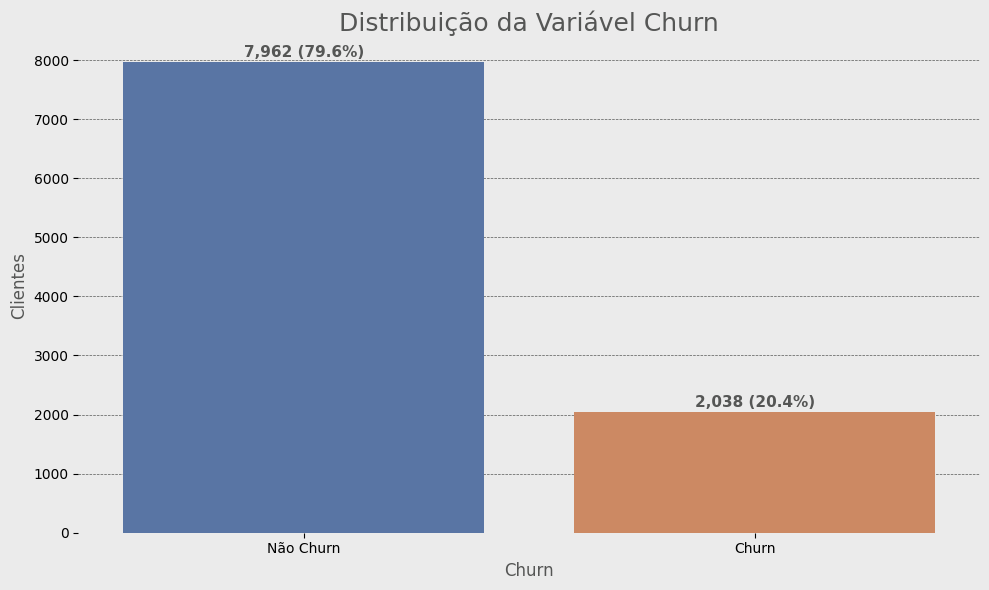

In [18]:
dist = df["Exited"].map({0: "Não Churn", 1: "Churn"}).value_counts().reindex(["Não Churn", "Churn"])

fig, ax = plot_vertical_bar(
    dist,
    title="Distribuição da Variável Churn",
    xlabel="Churn",
    ylabel="Clientes",
    palette=[cores["azul"], cores["laranja"]],
    bg_color=cores["cinza"],
    text_color=cores["cinza_escuro"],
    grid_color=cores["cinza_escuro"],
    label_mode="both"
)
plt.show()

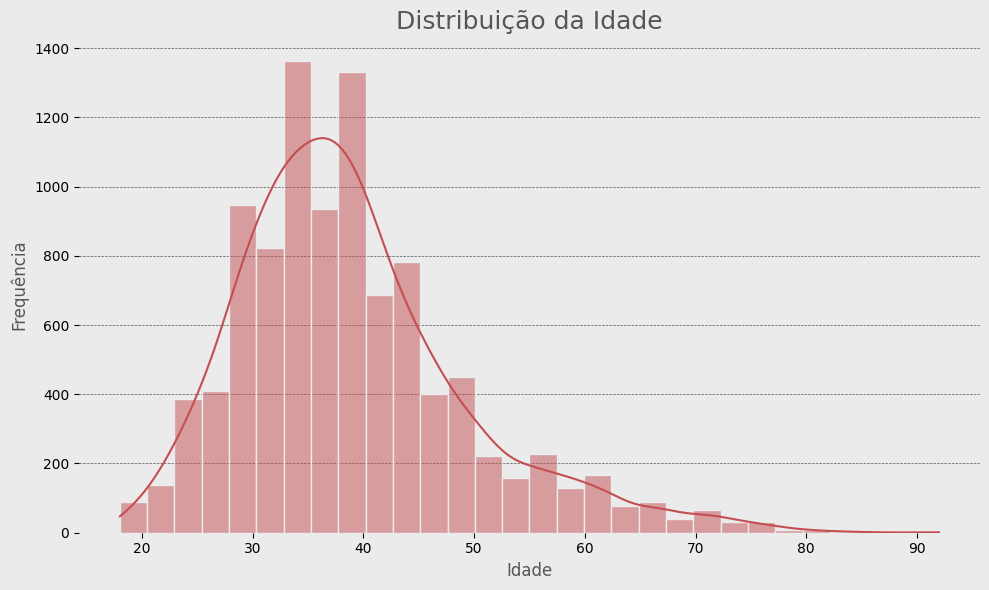

In [19]:
fig, ax = plot_histogram(
    df["Age"],
    title="Distribuição da Idade",
    xlabel="Idade",
    ylabel="Frequência",
    color=cores["vermelho"],
    discrete=False,
    xticks=range(0, 101, 5)
)

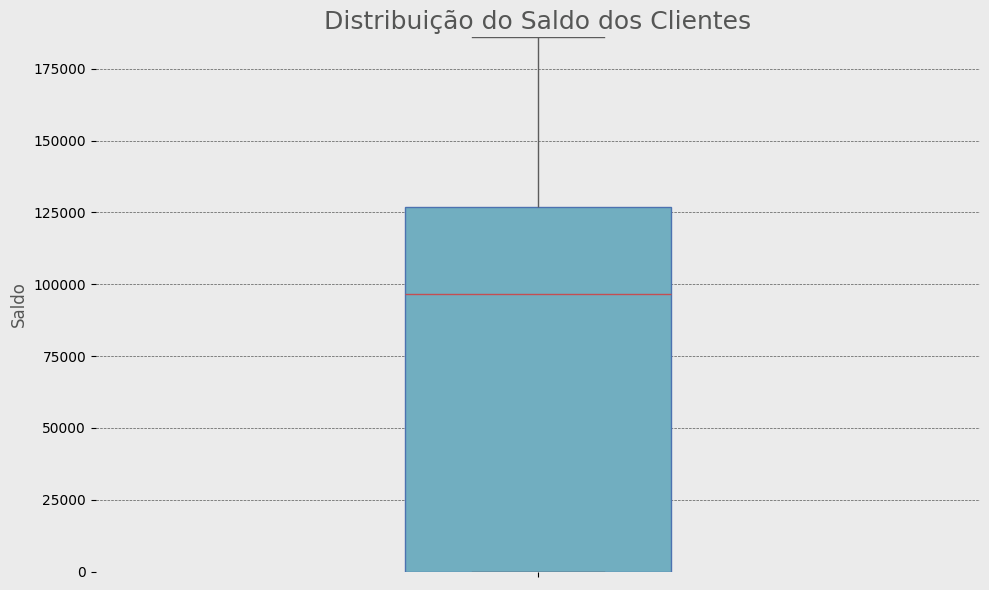

In [20]:
fig, ax = plot_boxplot(
    df["Balance"],
    title="Distribuição do Saldo dos Clientes",
    ylabel="Saldo",
    color=cores["azul_claro"],
    annotate=False
)

In [21]:
print(df['Geography'].value_counts(normalize=True) * 100)

Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64


In [22]:
dist_geo = df['Geography'].value_counts()
dist_geo_pct = df['Geography'].value_counts(normalize=True) * 100
tabela = pd.DataFrame({'Clientes': dist_geo, 'Percentual (%)': dist_geo_pct.round(1)})
print(tabela)

           Clientes  Percentual (%)
Geography                          
France         5014            50.1
Germany        2509            25.1
Spain          2477            24.8


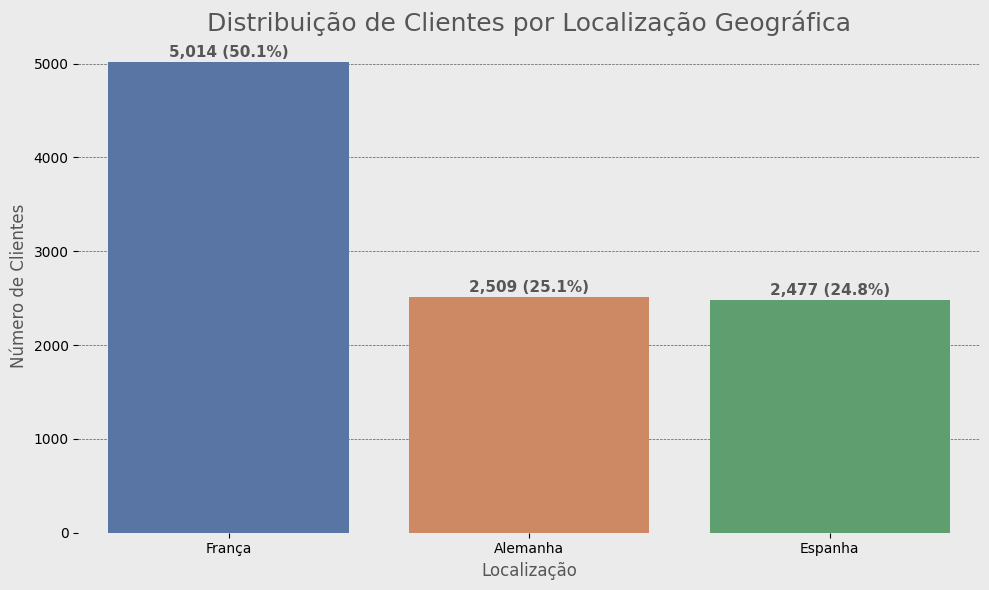

In [23]:
geography_labels = df["Geography"].map({
    "France": "França",
    "Germany": "Alemanha",
    "Spain": "Espanha"
})

dist = geography_labels.value_counts().reindex(["França", "Alemanha", "Espanha"])


fig, ax = plot_vertical_bar(
    dist,
    title="Distribuição de Clientes por Localização Geográfica",
    xlabel="Localização",
    ylabel="Número de Clientes",
    palette=[cores["azul"], cores["laranja"], cores["verde"]],
    label_mode="both"
)

In [24]:
print(df['Gender'].value_counts(normalize=True) * 100)

Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64


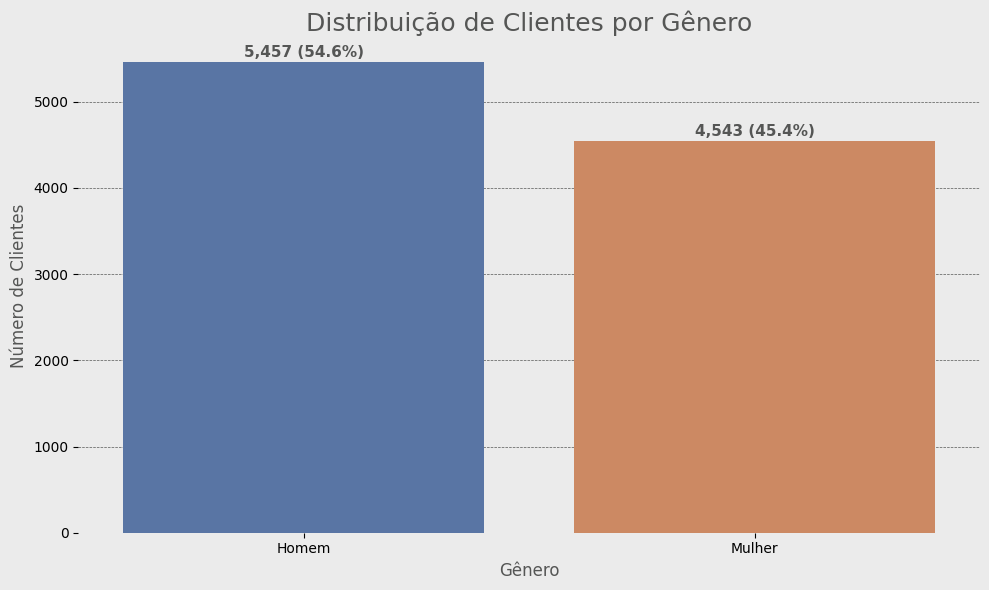

In [25]:
# Cria uma cópia APENAS para este gráfico
df_temp = df.copy()
df_temp["Gender_label"] = df_temp["Gender"].map({"Male": "Homem", "Female": "Mulher"})
dist = df_temp["Gender_label"].value_counts()

fig, ax = plot_vertical_bar(
    dist,
    title="Distribuição de Clientes por Gênero",
    xlabel="Gênero",
    ylabel="Número de Clientes",
    palette=[cores["azul"], cores["laranja"]],
    label_mode="both"
)

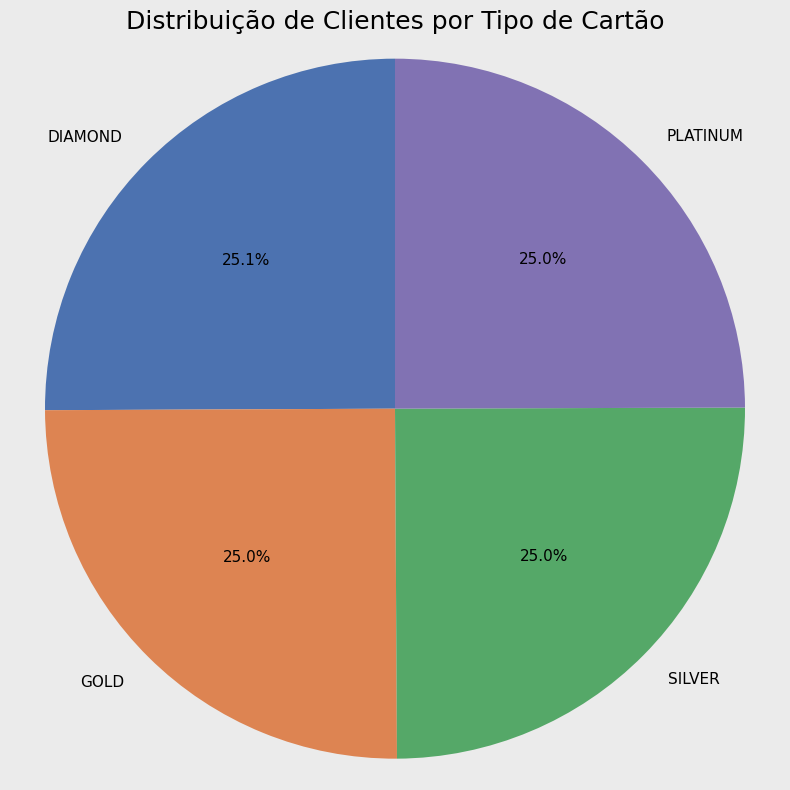

In [26]:
card_type_counts = df["Card Type"].value_counts()

fig, ax = plot_piechart(
    card_type_counts,
    title="Distribuição de Clientes por Tipo de Cartão",
    text_color = cores["preto"],
    annotate=False
)

### 3.2 Heatmap de Correlação

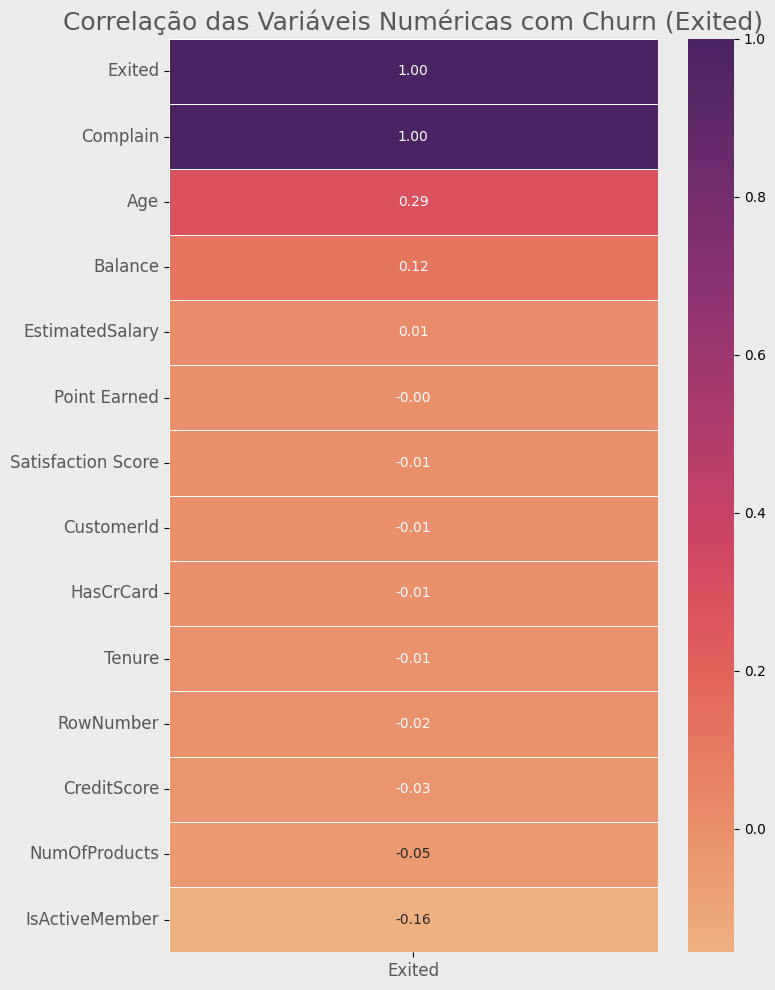

In [27]:
fig, ax = plot_vertical_heatmap(
    df,
    target_col="Exited",
    title="Correlação das Variáveis Numéricas com Churn (Exited)"
)

### 3.3 Detecção de Data Leakage

> **ALERTA CRÍTICO:** Durante a análise de correlação, a variável `Complain` apresentou correlação quase perfeita com `Exited`. Isso configura **Data Leakage** — a reclamação é consequência (ou indicador simultâneo) da saída, não uma causa preditiva. Incluí-la no modelo geraria acurácia artificialmente inflada (~99%) que não se sustentaria em produção.

In [28]:
# Investigando relação suspeita
correlação_complain = df['Complain'].corr(df['Exited'])
print(f"Correlação entre 'Complain' e 'Exited': {correlação_complain:.4f}")

Correlação entre 'Complain' e 'Exited': 0.9957


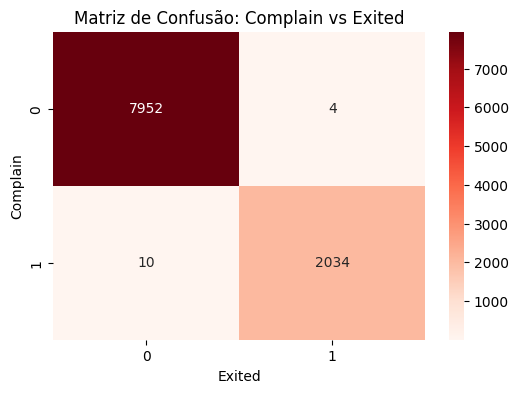

In [29]:
# Visualizando o problema
plt.figure(figsize=(6, 4))
sns.heatmap(pd.crosstab(df['Complain'], df['Exited']), annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusão: Complain vs Exited')
plt.show()

A matriz de confusão mostra uma classificação quase perfeita:
- Verdadeiros negativos: 7952
- Verdadeiros positivos: 2034
- Falsos positivos: 4
- Falsos negativos: 10

Isso resulta em uma acurácia extremamente alta, o que é raro em problemas reais, especialmente envolvendo variáveis como "Complain" e "Exited", que normalmente têm ruído e complexidade.

Essa relação é quase perfeita: se um cliente reclama, ele quase certamente fará churn, e se não reclama, quase certamente não fará churn. Uma correlação tão alta (0.9957 entre 'Complain' e 'Exited', como vimos na análise da correlação) em um cenário real é extremamente rara e sugere que a variável Complain não é uma característica independente que influencia o churn, mas sim um evento que acontece simultaneamente ou é uma consequência direta e imediata do churn, ou até mesmo um registro do próprio churn sob uma roupagem diferente.

O impacto de um data leak:

Se usarmos a coluna Complain diretamente para prever o churn, nosso modelo terá uma acurácia irrealisticamente alta no conjunto de treino, mas falhará miseravelmente em dados novos e não vistos. Isso porque essa variável 'vaza' a informação da variável alvo (Exited) para o modelo. Para construir um modelo preditivo robusto, Complain provavelmente precisaria ser removida ou tratada de forma muito específica, pois ela está, na prática, contando o churn em vez de prever o churn.


### 3.4 Análise Bivariada

## Churn (Exited) vs. Reclamação (Complain)

In [30]:
print(pd.crosstab(df['Complain'], df['Exited'], normalize='index') * 100)

Exited            0          1
Complain                      
0         99.949723   0.050277
1          0.489237  99.510763


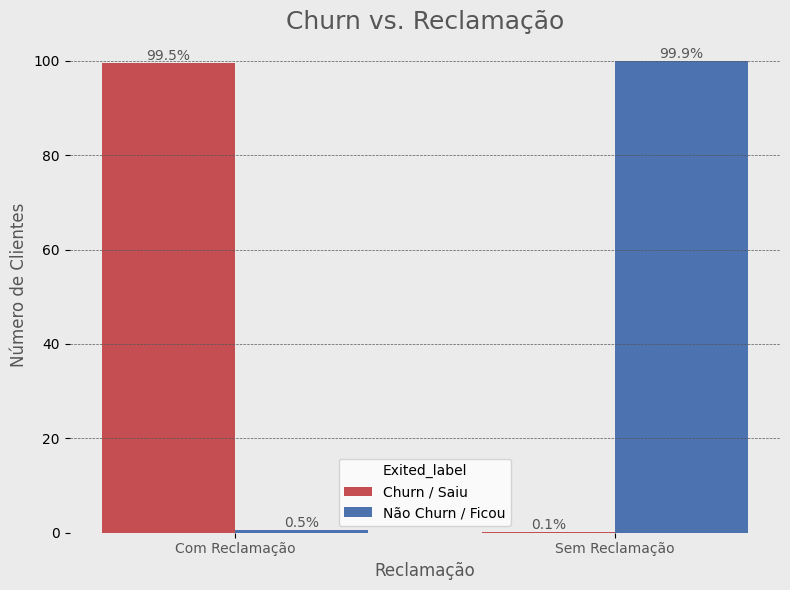

In [31]:
# Novamente, usamos uma cópia
df_plot = df.copy()
df_plot["Exited_label"] = df_plot["Exited"].map({0: "Não Churn / Ficou", 1: "Churn / Saiu"})
df_plot["Complain_label"] = df_plot["Complain"].map({0: "Sem Reclamação", 1: "Com Reclamação"})

fig, ax = plot_grouped_bar(
    df_plot,  # <--- Passando a cópia limpa
    x_col="Complain_label",
    hue_col="Exited_label",
    title="Churn vs. Reclamação",
    xlabel="Reclamação",
    ylabel="Número de Clientes",
    palette=[cores["vermelho"], cores["azul"]],
    value_mode="percent",
)

## Hipótese: Os Pontos Acumulados Influenciam a Probabilidade de Churn?"

Exited                0          1
Points_Level                      
Baixo         78.928429  21.071571
Médio         80.836653  19.163347
Alto          78.540088  21.459912
Muito Alto    80.177276  19.822724


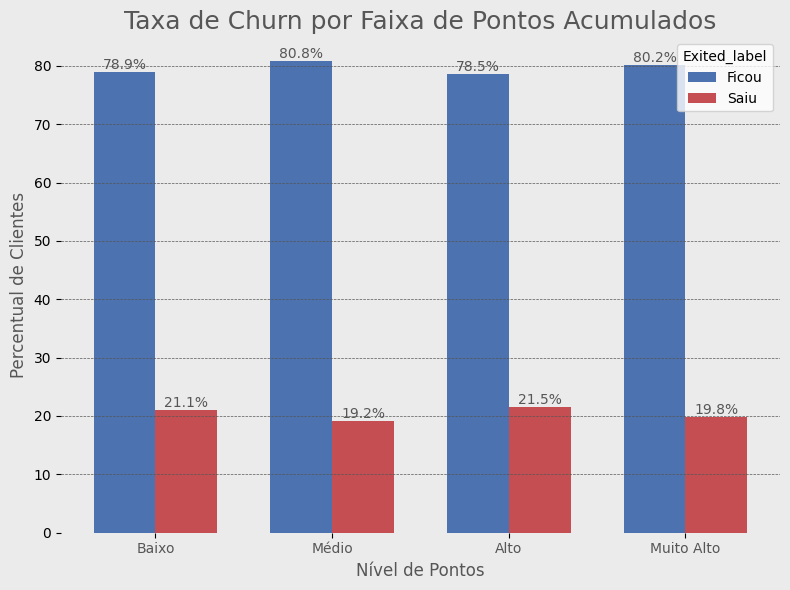

In [32]:
# 1. CRUCIAL: Criar uma cópia de trabalho ANTES de modificar qualquer coisa
# Assim o 'df' original continua intacto para o Machine Learning depois
df_temp = df.copy()

# 2. Criar faixas de pontos usando Quartis (qcut) NA CÓPIA
df_temp['Points_Level'] = pd.qcut(df_temp['Point Earned'], q=4, labels=['Baixo', 'Médio', 'Alto', 'Muito Alto'])

# 3. Verificar a Taxa de Churn (usando df_temp)
churn_por_pontos = pd.crosstab(df_temp['Points_Level'], df_temp['Exited'], normalize='index') * 100
print(churn_por_pontos)

# 4. Visualizar
# Criamos a label apenas para o gráfico, também na cópia
df_temp["Exited_label"] = df_temp["Exited"].map({0: "Ficou", 1: "Saiu"})

fig, ax = plot_grouped_bar(
    df_temp,  # <--- Usamos o df_temp
    x_col="Points_Level",
    hue_col="Exited_label",
    title="Taxa de Churn por Faixa de Pontos Acumulados",
    xlabel="Nível de Pontos",
    ylabel="Percentual de Clientes",
    palette=[cores["azul"], cores["vermelho"]],
    value_mode="percent"
)
plt.show()

## **Hipótese**: A idade influencia no Churn?

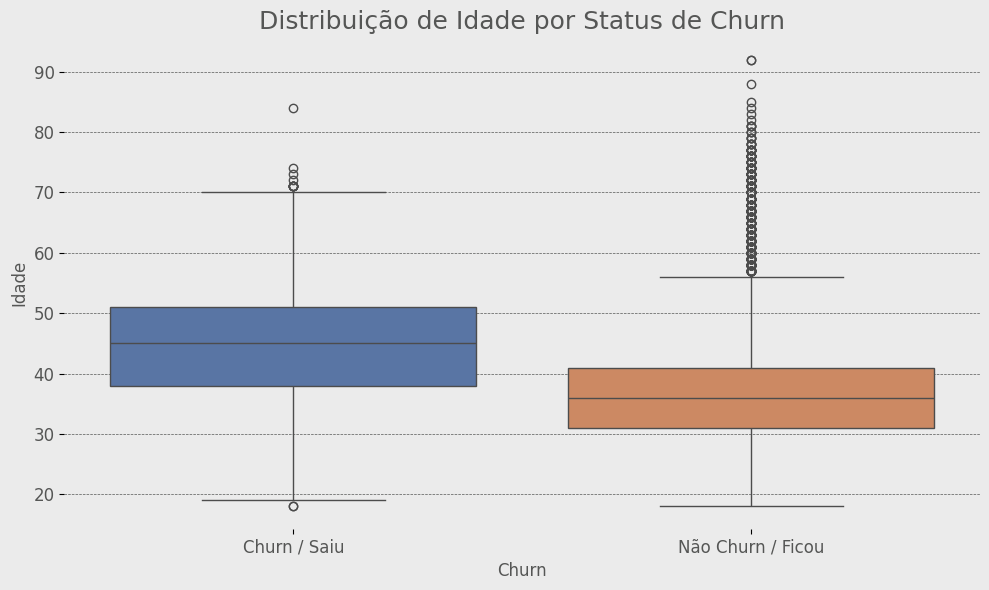

In [33]:
fig, ax = plot_boxplot_by_group(
    df,
    x_col="Exited",
    y_col="Age",
    title="Distribuição de Idade por Status de Churn",
    xlabel="Churn",
    ylabel="Idade",
    labels_map={0: "Não Churn / Ficou", 1: "Churn / Saiu"},
    palette=[cores["azul"], cores["laranja"]]
)

## **Hipótese**: Membros ativos têm realmente menor risco de churn

In [34]:
print(df.groupby(['IsActiveMember', 'Exited']).size())

IsActiveMember  Exited
0               0         3546
                1         1303
1               0         4416
                1          735
dtype: int64


In [35]:
print(pd.crosstab(df['IsActiveMember'], df['Exited']))

Exited             0     1
IsActiveMember            
0               3546  1303
1               4416   735


In [36]:
print(pd.crosstab(df['IsActiveMember'], df['Exited'], normalize='index') * 100)

Exited                  0          1
IsActiveMember                      
0               73.128480  26.871520
1               85.730926  14.269074


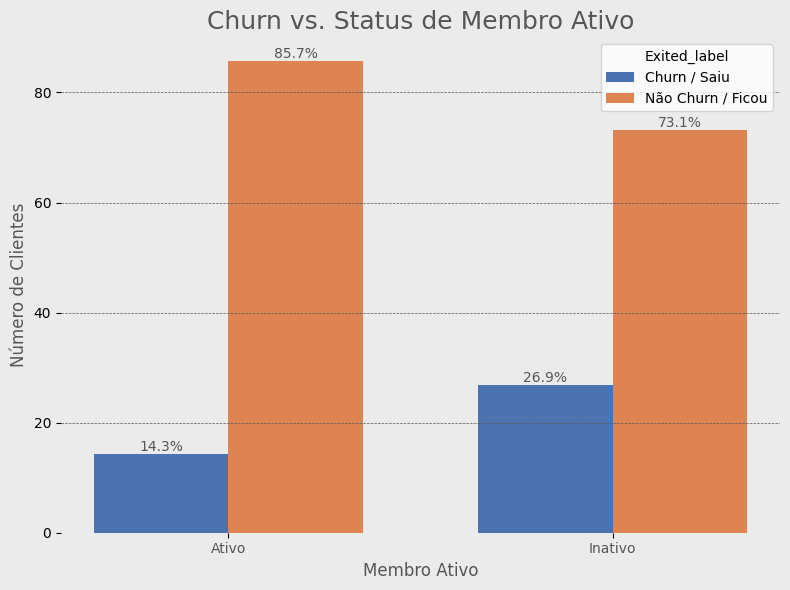

In [37]:
df_plot = df.copy()
df_plot["Active_label"] = df["IsActiveMember"].map({0: "Inativo", 1: "Ativo"})
df_plot["Exited_label"] = df["Exited"].map({0: "Não Churn / Ficou", 1: "Churn / Saiu"})

fig, ax = plot_grouped_bar(
    df_plot,
    x_col="Active_label",
    hue_col="Exited_label",
    title="Churn vs. Status de Membro Ativo",
    xlabel="Membro Ativo",
    ylabel="Número de Clientes",
    palette=[cores["azul"], cores["laranja"]],
    value_mode="percent"
)

## **Hipótese**: Existe alguma diferença notável nas taxas de churn entre os clientes da França, Alemanha e Espanha

In [38]:
print(pd.crosstab(df['Geography'], df['Exited'], normalize='index') * 100)

Exited             0          1
Geography                      
France     83.825289  16.174711
Germany    67.556796  32.443204
Spain      83.326605  16.673395


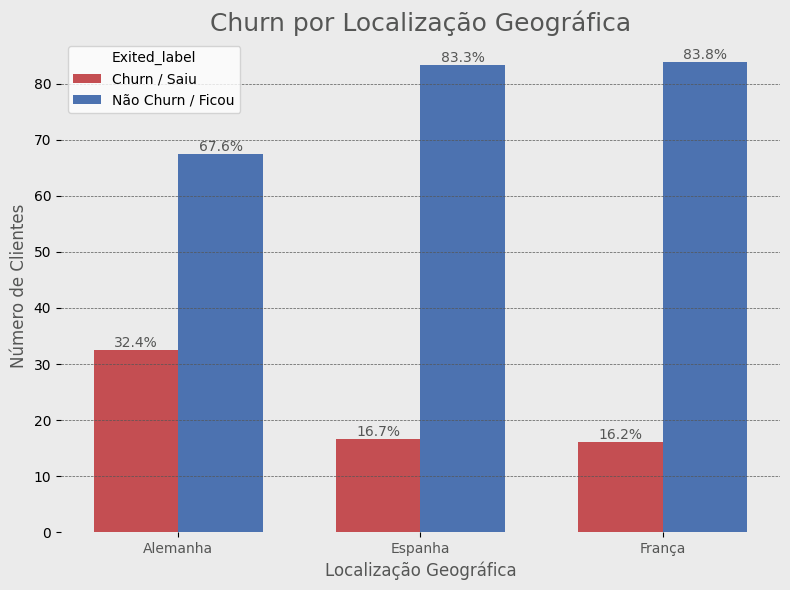

In [39]:
df_plot = df.copy()
df_plot["Geo_label"] = df["Geography"].map({"France": "França", "Germany": "Alemanha", "Spain": "Espanha"})
df_plot["Exited_label"] = df["Exited"].map({0: "Não Churn / Ficou", 1: "Churn / Saiu"})

fig, ax = plot_grouped_bar(
    df_plot,
    x_col="Geo_label",
    hue_col="Exited_label",
    title="Churn por Localização Geográfica",
    xlabel="Localização Geográfica",
    ylabel="Número de Clientes",
    palette=[cores["vermelho"], cores["azul"]],
    value_mode="percent"
)


## **Hippótese**: O gênero dos clientes influencia a probabilidade de churn?

In [40]:
pd.crosstab(df['Gender'], df['Exited'], normalize='index') * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.525747,16.474253


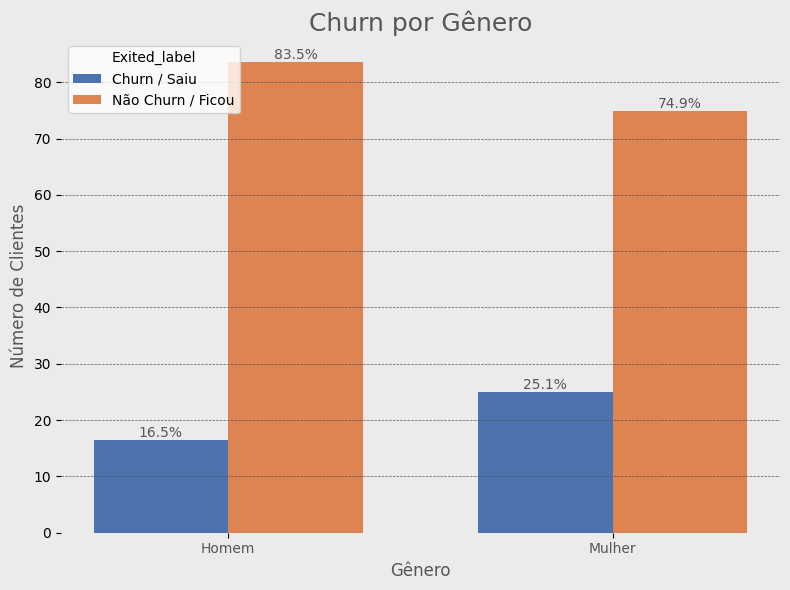

In [41]:
df_plot = df.copy()
df_plot["Gender_label"] = df["Gender"].map({"Male": "Homem", "Female": "Mulher"})
df_plot["Exited_label"] = df["Exited"].map({0: "Não Churn / Ficou", 1: "Churn / Saiu"})

fig, ax = plot_grouped_bar(
    df_plot,
    x_col="Gender_label",
    hue_col="Exited_label",
    title="Churn por Gênero",
    xlabel="Gênero",
    ylabel="Número de Clientes",
    palette=[cores["azul"], cores["laranja"]],
    value_mode="percent",
)

## **Hipótese**: O Saldo Bancário afeta a fidelidade

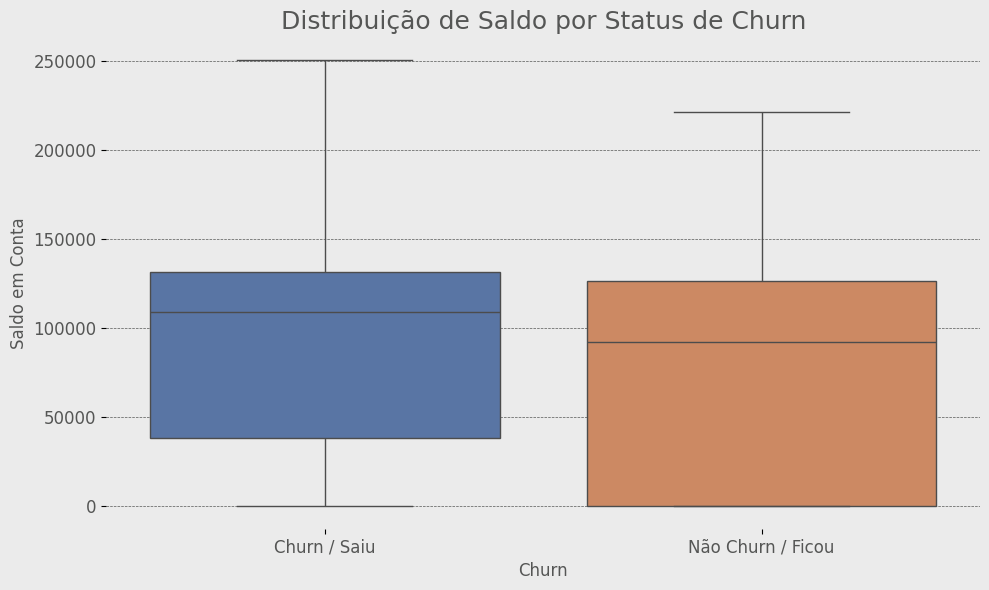

In [42]:
df_plot = df.copy()
df_plot["Exited_label"] = df["Exited"].map({0: "Não Churn / Ficou", 1: "Churn / Saiu"})

fig, ax = plot_boxplot_by_group(
    df_plot,
    x_col="Exited_label",
    y_col="Balance",
    title="Distribuição de Saldo por Status de Churn",
    xlabel="Churn",
    ylabel="Saldo em Conta",
    palette=[cores["azul"], cores["laranja"]]
)

### 3.5 Identificação de Outliers

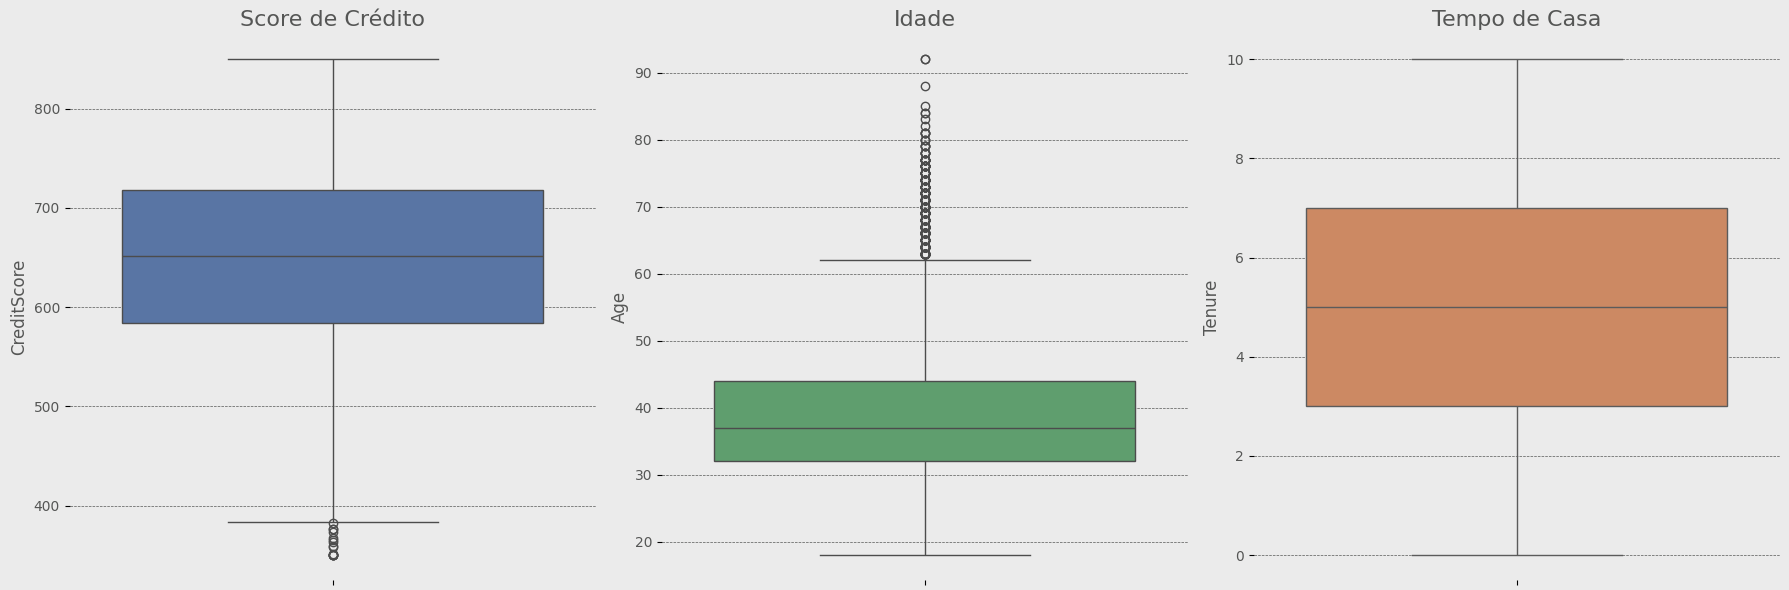

In [43]:
fig, ax = plot_multiple_boxplots(
    df,
    columns=["CreditScore", "Age", "Tenure"],
    titles=["Score de Crédito", "Idade", "Tempo de Casa"],
    colors=[cores["azul"], cores["verde"], cores["laranja"]],
    n_cols=3
)

### Análise de Outliers para CreditScore, Age e Tenure

Com base nos boxplots gerados:

*   **CreditScore:** O boxplot para 'CreditScore' mostra vários pontos de dados abaixo do bigode inferior, indicando a presença de **outliers com pontuações de crédito significativamente baixas**. Essas pontuações baixas podem representar um segmento de clientes com maior risco financeiro, o que pode ser um fator nas decisões de churn.

*   **Age:** O boxplot para 'Age' exibe diversos pontos de dados acima do bigode superior, sugerindo **outliers com idades incomumente altas**. Embora possam ser clientes válidos, vale investigar se clientes extremamente idosos se comportam de forma diferente em relação aos serviços bancários ou ao churn. Por outro lado, também há alguns pontos abaixo do bigode inferior, representando clientes muito jovens, embora em menor número.

*   **Tenure:** O boxplot para 'Tenure' parece mostrar uma distribuição relativamente uniforme com **poucos ou nenhum outlier significativo**. A maioria dos pontos de dados está dentro dos bigodes, indicando que a duração do relacionamento dos clientes com o banco é em grande parte consistente, sem desvios extremos. Isso sugere que 'Tenure' pode ser uma variável mais estável do que 'CreditScore' ou 'Age' em termos de presença de outliers.

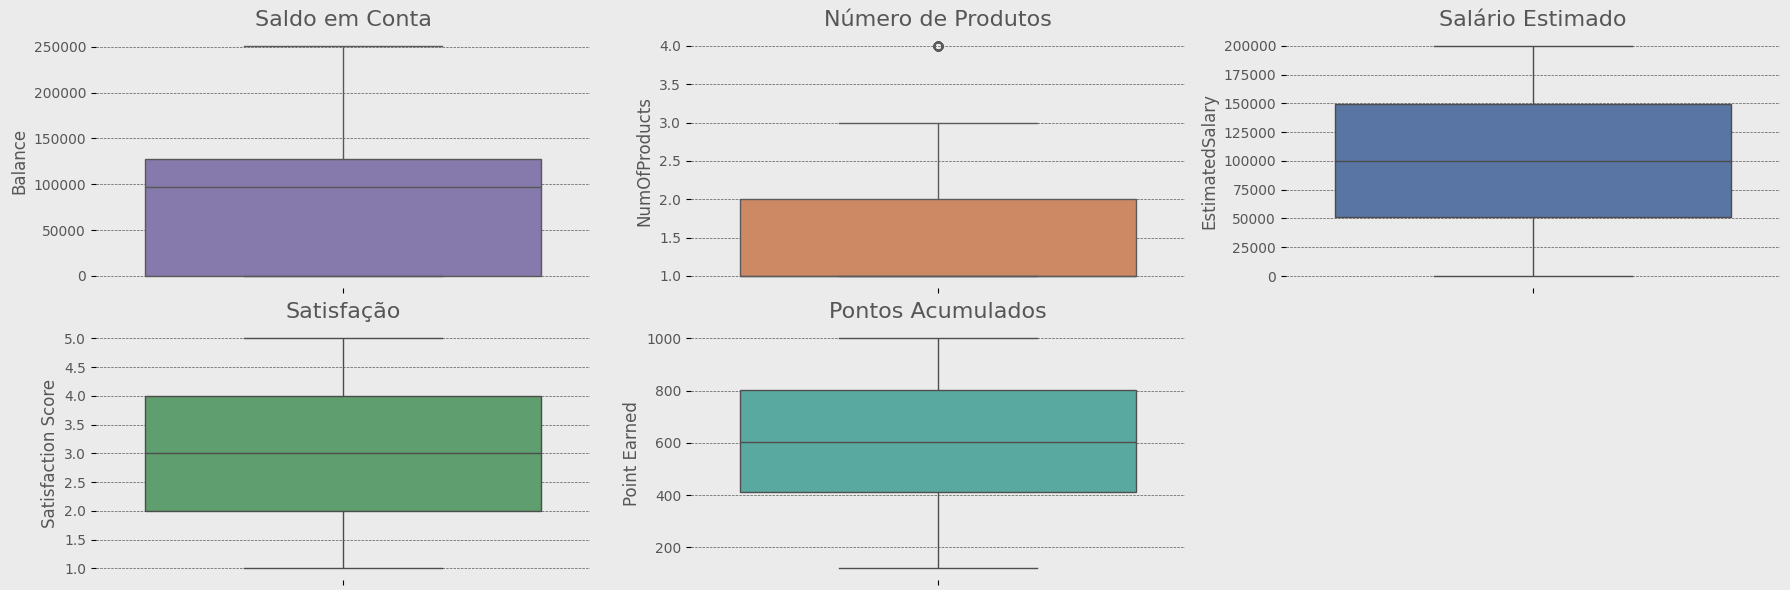

In [44]:
fig, ax = plot_multiple_boxplots(
    df,
    columns=[
        "Balance",
        "NumOfProducts",
        "EstimatedSalary",
        "Satisfaction Score",
        "Point Earned"
    ],
    titles=[
        "Saldo em Conta",
        "Número de Produtos",
        "Salário Estimado",
        "Satisfação",
        "Pontos Acumulados"
    ],
    colors=[
        cores["roxo"],        # Balance
        cores["laranja"],     # NumOfProducts
        cores["azul"],        # EstimatedSalary
        cores["verde"],       # Satisfaction Score
        cores["verde_agua"]   # Point Earned
    ],
    n_cols=3,
    bg_color=cores["cinza"],
    text_color=cores["cinza_escuro"],
    grid_color=cores["cinza_escuro"]
)


### Análise de Outliers para Balance, NumOfProducts, EstimatedSalary, Satisfaction Score e Point Earned

Com base nos boxplots gerados:

*   **Balance:** O boxplot para 'Balance' confirma nossa observação anterior de um número significativo de clientes com saldo zero. Entre os clientes com saldo, não há outliers extremos, e a distribuição parece relativamente uniforme acima de zero, sem pontos significativamente distantes do corpo principal dos dados. A alta concentração em zero é uma característica importante, não necessariamente um outlier no sentido tradicional, mas um aspecto relevante dos dados.

*   **NumOfProducts:** O boxplot para 'NumOfProducts' mostra que a maioria dos clientes possui 1 ou 2 produtos. Há alguns clientes com 3 ou 4 produtos, que aparecem como outliers. Embora sejam tecnicamente outliers pela regra do IQR, ter 3 ou 4 produtos ainda é um cenário plausível e pode representar segmentos específicos de clientes, em vez de dados incorretos.

*   **EstimatedSalary:** O boxplot de 'EstimatedSalary' indica uma ampla faixa de salários, mas com **nenhum outlier significativo**. A distribuição parece relativamente uniforme ao longo do espectro, sugerindo que os salários estão bem distribuídos sem valores extremos que se desviem muito do conjunto principal dos dados.

*   **Satisfaction Score:** O boxplot de 'Satisfaction Score' mostra uma variação de 1 a 5, que provavelmente são categorias pré-definidas de satisfação. Assim, **não há outliers** nessa variável; todos os valores estão dentro da faixa esperada, indicando uma escala categórica em vez de contínua, onde normalmente se encontrariam outliers.

*   **Point Earned:** O boxplot de 'Point Earned' mostra uma distribuição contínua com **nenhum outlier significativo**. Os pontos ganhos parecem estar distribuídos sem valores extremos, sugerindo um sistema de recompensas ou padrão de engajamento dos clientes consistente.

## Resumo dos Achados de Outliers e Visão Geral dos Outliers nas Colunas Numéricas:

Com base nos boxplots gerados para todas as variáveis numéricas, podemos resumir a presença e a natureza dos outliers da seguinte forma:

*   **CreditScore:** O boxplot mostra claramente um número significativo de pontos de dados abaixo do bigode inferior, indicando **outliers com pontuações de crédito muito baixas**. Essas pontuações extremamente baixas podem representar clientes com saúde financeira precária ou novos clientes com histórico de crédito limitado. Seu impacto potencial no churn é alto, já que pontuações de crédito mais baixas podem estar correlacionadas com maior risco de inadimplência ou insatisfação com os serviços bancários, levando ao churn. Esta coluna pode exigir **tratamento** (por exemplo, capping, transformação ou consideração cuidadosa durante a modelagem) ou investigação adicional para compreender esses clientes.

*   **Age:** O boxplot de 'Age' exibe vários pontos de dados acima do bigode superior, indicando **outliers representando idades incomumente altas**. Há também alguns pontos abaixo do bigode inferior para clientes muito jovens. Clientes extremamente idosos ou muito jovens podem ter necessidades bancárias diferentes ou fatores distintos de churn. A presença desses outliers exige **investigação adicional** para confirmar se são pontos de dados válidos ou erros, e para avaliar seu comportamento diferenciado em relação ao churn.

*   **Tenure:** Esta coluna parece ser relativamente estável, com **poucos ou nenhum outlier significativo**. A maioria dos pontos de dados está dentro dos bigodes, sugerindo uma distribuição consistente da duração do relacionamento dos clientes com o banco. Essa variável parece menos problemática em termos de valores extremos.

*   **Balance:** Como observado anteriormente, um grande agrupamento de pontos de dados com saldo zero distorce significativamente a distribuição. Para saldos diferentes de zero, o boxplot mostra alguns **outliers em valores de saldo mais altos**. Os casos de saldo zero não são outliers no sentido estatístico, mas representam um grupo distinto que requer atenção especial. Outliers de saldo elevado devem ser investigados, pois podem representar clientes de alto valor cujo churn teria impacto particularmente relevante.

*   **NumOfProducts:** O boxplot indica **outliers em clientes que possuem 3 ou 4 produtos**. Embora possam ser casos válidos, são menos comuns do que 1 ou 2 produtos. Esses outliers podem indicar relacionamentos mais complexos ou pacotes específicos de produtos. Seu impacto no churn deve ser analisado para verificar se possuir muitos produtos (ou poucos) influencia a retenção.

*   **EstimatedSalary:** O boxplot de 'EstimatedSalary' mostra uma distribuição relativamente uniforme, com **nenhum outlier extremo evidente**. A dispersão parece ampla, mas sem pontos claramente afastados da distribuição principal, indicando que os valores de salário estão geralmente dentro das faixas esperadas para a base de clientes.

*   **Satisfaction Score:** Como esta é uma variável semelhante a categórica (1 a 5), os valores extremos são definidos pela própria escala. O boxplot mostra a distribuição entre esses valores discretos. Não há outliers estatísticos tradicionais aqui, mas sim diferentes níveis de satisfação. Todos os valores estão dentro da faixa esperada (1-5), portanto **não é necessário tratamento de outliers** no sentido convencional.

*   **Point Earned:** O boxplot de 'Point Earned' mostra uma distribuição ampla com **nenhum outlier discernível**. Os pontos ganhos parecem variar entre os clientes sem desvios extremos, sugerindo que esta variável é bastante estável.

### 3.6 Principais Achados

## Principais Achados da Análise de Dados / Insights

*   **CreditScore** apresenta outliers significativos com pontuações muito baixas, o que pode indicar maior risco financeiro.  
*   **Age** mostra outliers em idades incomumente altas e muito jovens.  
*   **Tenure** apresenta poucos ou nenhum outlier significativo.  
*   **Balance** possui um grande número de saldos zerados e alguns outliers de alto valor.  
*   **NumOfProducts** identifica outliers em clientes que possuem 3 ou 4 produtos.  
*   **EstimatedSalary** e **Point Earned** não exibem outliers significativos.  
*   **Satisfaction Score** não possui outliers estatísticos tradicionais, já que é uma variável semelhante a categórica (1-5).  

### Principais Achados da Análise de Dados  
*   **CreditScore** apresenta numerosos outliers com pontuações significativamente baixas, sugerindo um segmento de clientes com potencialmente maior risco financeiro.  
*   **Age** mostra outliers em ambas as extremidades do espectro, com idades incomumente altas (acima do bigode superior) e algumas muito jovens (abaixo do bigode inferior).  
*   **Tenure** exibe uma distribuição relativamente estável com poucos ou nenhum outlier significativo, indicando consistência na duração do relacionamento dos clientes com o banco.  
*   **Balance** é caracterizado por um agrupamento significativo de clientes com saldo zero e, entre aqueles com saldo diferente de zero, alguns outliers de alto valor estão presentes.  
*   **NumOfProducts** identifica clientes com 3 ou 4 produtos como outliers, embora esses sejam cenários plausíveis e não dados incorretos.  
*   **EstimatedSalary** e **Point Earned** mostram distribuições amplas e relativamente uniformes, sem outliers extremos claros.  
*   **Satisfaction Score** não contém outliers estatísticos, já que seus valores (1-5) representam níveis categóricos pré-definidos.   


---
## 4. Feature Engineering
---

Criação de variáveis sintéticas para capturar comportamentos financeiros complexos.

> **Nota Técnica:** Constante `epsilon` (1e-6) em todas as divisões para evitar ZeroDivisionError.

| Feature | Lógica |
|---|---|
| `CreditScoreGivenAge` | Score normalizado pela idade — 600 é bom para jovem, ruim para idoso |
| `HasBalance` | Flag binária — clientes com saldo zero tendem a ser "fantasmas" |
| `PointsPerProduct` | Engajamento real — pontos por produto contratado |
| `BalanceSalaryRatio` | Capacidade de poupança — saldo relativo ao salário |
| `TenureByAge` | Fidelidade proporcional à idade do cliente |

In [45]:
# ==============================================================================
# 2. ENGENHARIA DE ATRIBUTOS (FEATURE ENGINEERING)
# ==============================================================================
# Criar cópia para não alterar o original
df_feat = df.copy()

# Constante de segurança para evitar divisão por zero
epsilon = 1e-6

# --- Criação das Variáveis Estratégicas ---

# 1. Normalização de comportamento (Score / Idade)
df_feat['CreditScoreGivenAge'] = df_feat['CreditScore'] / (df_feat['Age'] + epsilon)

# 2. Captura do efeito "Saldo Zero"
df_feat['HasBalance'] = df_feat['Balance'].apply(lambda x: 1 if x > 0 else 0)

# 3. Engajamento real (Pontos / Produtos)
df_feat['PointsPerProduct'] = df_feat['Point Earned'] / (df_feat['NumOfProducts'] + epsilon)

# 4. Capacidade de Poupança (Saldo / Salário)
df_feat['BalanceSalaryRatio'] = df_feat['Balance'] / (df_feat['EstimatedSalary'] + epsilon)

# 5. Fidelidade proporcional à vida do cliente
df_feat['TenureByAge'] = df_feat['Tenure'] / (df_feat['Age'] + epsilon)

---
## 5. Modelagem
---

### 5.1 Preparação dos Dados

Removemos IDs e a coluna `Complain` (Data Leakage identificado na EDA). As variáveis categóricas ficam como texto — o Pipeline faz o encoding internamente.

In [46]:
# ==============================================================================
# 3. PREPARAÇÃO PARA O PIPELINE
# ==============================================================================

# Limpeza Básica: Removemos IDs e a coluna 'Complain' (Data Leakage)
# IMPORTANTE: NÃO fazemos get_dummies aqui. Deixamos o texto cru para o Pipeline.
colunas_para_remover = ['RowNumber', 'CustomerId', 'Surname', 'Complain']
df_feat = df_feat.drop(colunas_para_remover, axis=1)

# Separar X e y
X = df_feat.drop('Exited', axis=1)
y = df_feat['Exited']

# Definir colunas para o Pipeline
colunas_cat = ['Geography', 'Gender', 'Card Type']

# Identificar colunas numéricas de forma robusta
colunas_num = X.select_dtypes(include=np.number).columns.tolist()

# Garantir que nenhuma coluna de label temporária (criada para visualização) esteja em colunas_num
# Essas colunas podem ter sido adicionadas ao `df` principal após a criação de `df_feat`, mas antes da definição de `X`.
temporary_label_cols = ['Gender_label', 'Exited_label', 'Complain_label', 'Points_Level', 'Active_label']
colunas_num = [c for c in colunas_num if c not in temporary_label_cols]

# Garantir que as colunas categóricas para OneHotEncoder estão presentes em X
colunas_cat = [c for c in colunas_cat if c in X.columns]

In [47]:
# Divisão Treino/Teste (80/20, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
print(f"Proporção Churn no treino: {y_train.mean():.2%}")
print(f"Proporção Churn no teste:  {y_test.mean():.2%}")

Treino: 8000 | Teste: 2000
Proporção Churn no treino: 20.38%
Proporção Churn no teste:  20.40%


### 5.2 Comparação de Modelos

Testamos 3 modelos com o mesmo pipeline (preprocessamento + SMOTE) para fundamentar a escolha do XGBoost. Avaliação via **validação cruzada estratificada (5-fold)** com Recall como métrica principal.

In [48]:
# ==============================================================================
# COMPARAÇÃO DE MODELOS COM CROSS-VALIDATION
# ==============================================================================

# Preprocessador comum
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', colunas_num),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), colunas_cat)
    ]
)

# Modelos candidatos
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
}

# Cross-validation estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}

for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', modelo)
    ])

    # Recall como métrica principal (custo alto de falso negativo)
    scores_recall = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall')
    scores_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    scores_roc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

    resultados[nome] = {
        'Recall': f"{scores_recall.mean():.4f} ± {scores_recall.std():.4f}",
        'F1-Score': f"{scores_f1.mean():.4f} ± {scores_f1.std():.4f}",
        'AUC-ROC': f"{scores_roc.mean():.4f} ± {scores_roc.std():.4f}",
        'recall_mean': scores_recall.mean()
    }
    print(f"✓ {nome}: Recall={scores_recall.mean():.4f} | F1={scores_f1.mean():.4f} | AUC={scores_roc.mean():.4f}")

# Tabela comparativa
df_resultados = pd.DataFrame(resultados).T.drop(columns='recall_mean')
print("\n--- COMPARAÇÃO DE MODELOS (5-Fold Cross-Validation) ---")
display(df_resultados)

# Identificar melhor modelo
melhor = max(resultados, key=lambda k: resultados[k]['recall_mean'])
print(f"\n→ Melhor modelo por Recall: {melhor}")

✓ Logistic Regression: Recall=0.7252 | F1=0.4809 | AUC=0.7514
✓ Random Forest: Recall=0.4945 | F1=0.5903 | AUC=0.8509
✓ XGBoost: Recall=0.5025 | F1=0.5925 | AUC=0.8614

--- COMPARAÇÃO DE MODELOS (5-Fold Cross-Validation) ---


,Recall,F1-Score,AUC-ROC
Logistic Regression,0.7252 ± 0.0161,0.4809 ± 0.0115,0.7514 ± 0.0083
Random Forest,0.4945 ± 0.0081,0.5903 ± 0.0082,0.8509 ± 0.0089
XGBoost,0.5025 ± 0.0098,0.5925 ± 0.0120,0.8614 ± 0.0079



→ Melhor modelo por Recall: Logistic Regression


### 5.3 Pipeline Final (XGBoost)

Por que XGBoost? Na comparação por cross-validation, Logistic Regression apresentou maior Recall bruto (72,5%), porém com F1 e AUC-ROC significativamente inferiores. O XGBoost, com threshold otimizado para 30%, alcança Recall equivalente (71,8%) com melhor capacidade de discriminação (AUC 0.86 vs 0.75). A combinação de recall competitivo + menor taxa de falsos positivos torna o XGBoost a melhor escolha para produção, onde alertas excessivos errados geram custo operacional

In [49]:
# ==============================================================================
# PIPELINE FINAL DE PRODUÇÃO
# ==============================================================================

pipeline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

print("Treinando pipeline final...")
pipeline_model.fit(X_train, y_train)
print("Pipeline treinado!")

Treinando pipeline final...
Pipeline treinado!


### 5.4 Otimização de Threshold

Modelos padrão usam 50% como corte de decisão. No churn, o custo de **não detectar** um cliente saindo (Falso Negativo) é muito maior que abordar alguém que ficaria (Falso Positivo).

**Estratégia:** Baixamos o threshold para **30%** — aumenta o Recall, aceitando leve queda na Precisão.


--- Performance com Régua Otimizada (30.0%) ---
Acurácia:  83.15%
Recall:    71.81% (Métrica Principal)
Precision: 56.89%
----------------------------------------


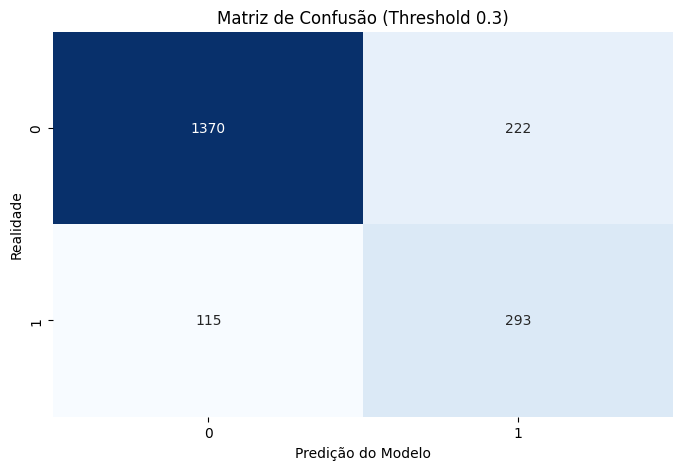

In [50]:
# ==============================================================================
# 5. AVALIAÇÃO E OTIMIZAÇÃO (THRESHOLD TUNING)
# ==============================================================================

# Gerar probabilidades
y_proba = pipeline_model.predict_proba(X_test)[:, 1]

# Definir a régua de corte Otimizada
threshold = 0.30
y_pred_opt = (y_proba >= threshold).astype(int)

# Métricas
print(f"\n--- Performance com Régua Otimizada ({threshold*100}%) ---")
print(f"Acurácia:  {accuracy_score(y_test, y_pred_opt):.2%}")
print(f"Recall:    {recall_score(y_test, y_pred_opt):.2%} (Métrica Principal)")
print(f"Precision: {precision_score(y_test, y_pred_opt):.2%}")
print("-" * 40)

# Matriz de Confusão
plt.figure(figsize=(8, 5))
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusão (Threshold {threshold})')
plt.xlabel('Predição do Modelo')
plt.ylabel('Realidade')
plt.show()

---
## 6. Interpretabilidade (SHAP)
---

SHAP (SHapley Additive exPlanations) mostra a contribuição de cada variável para as predições, permitindo explicar **por que** o modelo tomou cada decisão.

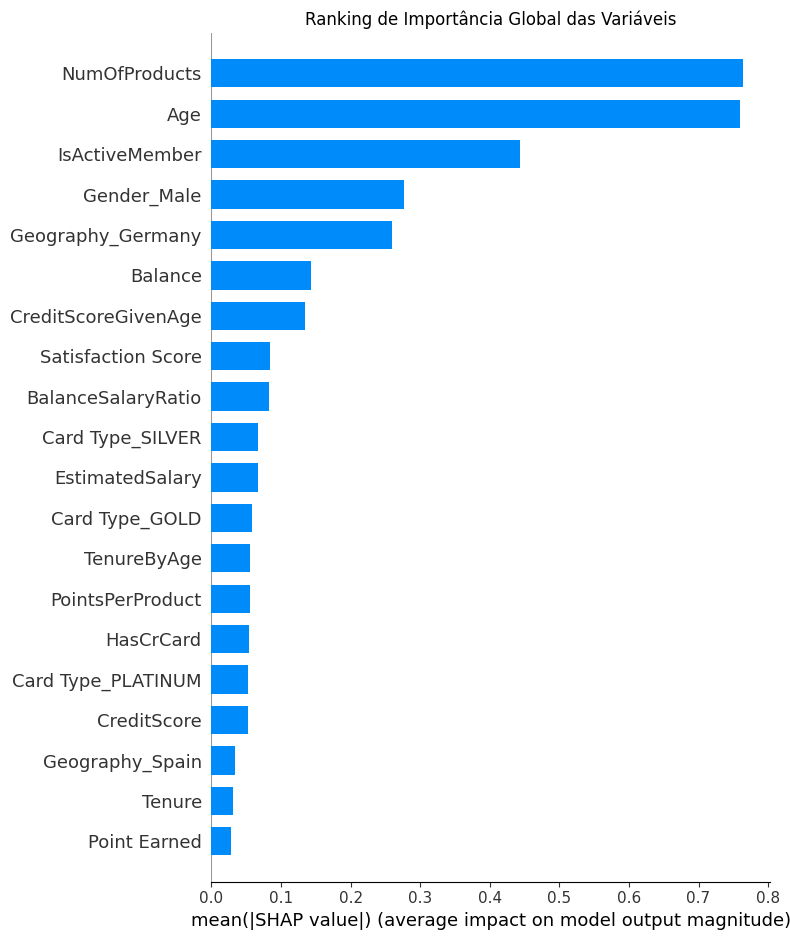

In [51]:
# ==============================================================================
# 6. INTERPRETABILIDADE (SHAP)
# ==============================================================================
try:
    # Hack para acessar o modelo DENTRO do pipeline
    model_step = pipeline_model.named_steps['classifier']
    preprocessor_step = pipeline_model.named_steps['preprocessor']

    # Transformamos o X_test para o formato que o modelo entende (numeros)
    X_test_transformed = preprocessor_step.transform(X_test)

    # Pegamos os nomes das colunas geradas pelo OneHotEncoder
    ohe_cols = preprocessor_step.named_transformers_['cat'].get_feature_names_out(colunas_cat)
    all_cols = colunas_num + list(ohe_cols)

    # SHAP
    explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(X_test_transformed)

    plt.figure(figsize=(10, 6))
    plt.title('Ranking de Importância Global das Variáveis')
    shap.summary_plot(shap_values, X_test_transformed, feature_names=all_cols, plot_type="bar", show=False)
    plt.show()
except Exception as e:
    print(f"Pulo na visualização SHAP (Complexidade de Pipeline): {e}")

---
## 7. Impacto Financeiro (ROI)
---

Data Science precisa gerar valor mensurável. Simulamos o impacto do modelo no P&L do banco.

**Premissas conservadoras:**

| Parâmetro | Valor | Justificativa |
|---|---|---|
| LTV médio | R$ 5.000 | Lucro vitalício estimado por cliente |
| Custo de retenção | R$ 150 | Campanha (desconto, contato, tempo de gerente) |
| Taxa de sucesso | 50% | Estimativa conservadora de clientes salvos |

In [52]:
# ---------------------------------------------------------
# SIMULAÇÃO FINANCEIRA (BUSINESS VALUE)
# ---------------------------------------------------------

# 1. Premissas de Negócio (Hipóteses)
# Quanto lucro um cliente médio gera para o banco ao longo da vida (LTV)?
LTV_MEDIO = 5000.00  # Ex: R$ 5.000,00 de lucro vitalício

# Quanto custa tentar reter um cliente? (Desconto, ligação, e-mail mkt, tempo do gerente)
CUSTO_RETENCAO = 150.00  # Ex: R$ 150,00

# Se abordarmos um cliente que ia sair, qual a chance de convencê-lo a ficar?
TAXA_SUCESSO_RETENCAO = 0.50  # 50% de chance de salvar o cliente

# 2. Extraindo os números do modelo (Matriz de Confusão)
# TN = True Negative (Ficou e previmos que ficaria)
# FP = False Positive (Ficou, mas alertamos que sairia -> Gasto à toa)
# FN = False Negative (Saiu e não vimos -> Prejuízo total)
# TP = True Positive (Saiu e nós avisamos -> Chance de salvar!)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()

# 3. Cálculos Financeiros

# Cenário A: Sem Modelo (Não fazemos nada, perdemos todos que saem)
# Prejuízo: Todos os que saíram (TP + FN) * LTV
prejuizo_sem_modelo = (tp + fn) * LTV_MEDIO

# Cenário B: Com Nosso Modelo XGBoost
# Custo Operacional: Gastamos com TODOS que o modelo alertou (TP + FP)
custo_campanha = (tp + fp) * CUSTO_RETENCAO

# Receita Salva: Dos que acertamos (TP), salvamos uma porcentagem (TAXA_SUCESSO)
clientes_salvos = tp * TAXA_SUCESSO_RETENCAO
receita_salva = clientes_salvos * LTV_MEDIO

# Resultado Final
lucro_modelo = receita_salva - custo_campanha

# 4. Apresentação dos Resultados
roi_df = pd.DataFrame({
    "Métrica": [
        "Clientes em Risco Detectados (Recall)",
        "Clientes Salvos (Estimat. 50%)",
        "Custo da Campanha (Retenção)",
        "Receita Salva (LTV)",
        "LUCRO LÍQUIDO DO MODELO"
    ],
    "Valor": [
        f"{tp} clientes",
        f"{int(clientes_salvos)} clientes",
        f"R$ {custo_campanha:,.2f}",
        f"R$ {receita_salva:,.2f}",
        f"R$ {lucro_modelo:,.2f}"
    ]
})

print("--- RELATÓRIO DE IMPACTO FINANCEIRO ---")
print(f"Base de Teste: {len(y_test)} clientes")
display(roi_df)

print(f"\nConclusão: Ao implementar este modelo, o banco deixa de perder R$ {prejuizo_sem_modelo:,.2f} (cenário inerte)")
print(f"e passa a gerar um resultado positivo líquido de R$ {lucro_modelo:,.2f}.")

--- RELATÓRIO DE IMPACTO FINANCEIRO ---
Base de Teste: 2000 clientes


,Métrica,Valor
0,Clientes em Risco Detectados (Recall),293 clientes
1,Clientes Salvos (Estimat. 50%),146 clientes
2,Custo da Campanha (Retenção),"R$ 77,250.00"
3,Receita Salva (LTV),"R$ 732,500.00"
4,LUCRO LÍQUIDO DO MODELO,"R$ 655,250.00"



Conclusão: Ao implementar este modelo, o banco deixa de perder R$ 2,040,000.00 (cenário inerte)
e passa a gerar um resultado positivo líquido de R$ 655,250.00.


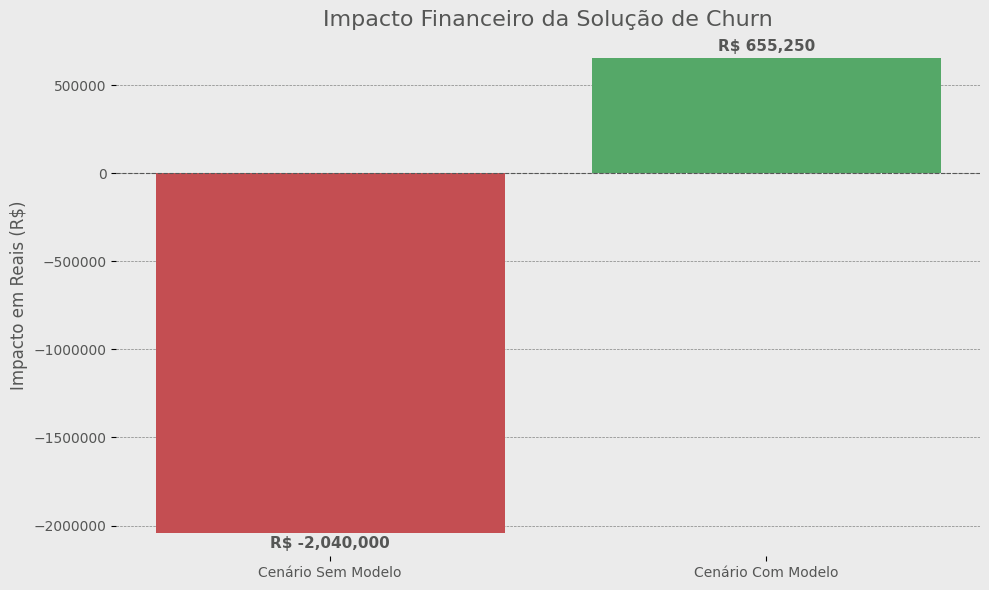

In [53]:
# Visualização do ROI
bg_color = cores["cinza"]
text_color = cores["cinza_escuro"]
grid_color = cores["cinza_escuro"]

fig, ax = plt.subplots(figsize=(10, 6), facecolor=bg_color) # Increased figsize, added facecolor
ax.set_facecolor(bg_color) # Set axes facecolor

cenarios = ['Cenário Sem Modelo', 'Cenário Com Modelo'] # More descriptive labels
valores = [-prejuizo_sem_modelo, lucro_modelo] # Prejuízo como negativo para impacto visual
cores_roi = [cores["vermelho"], cores["verde"]] # Use predefined colors

bars = ax.bar(cenarios, valores, color=cores_roi)
ax.axhline(0, color=text_color, linewidth=0.8, linestyle='--') # Thinner, dashed line

ax.set_title('Impacto Financeiro da Solução de Churn', fontsize=16, color=text_color) # Updated title, font size
ax.set_ylabel('Impacto em Reais (R$)', fontsize=12, color=text_color) # Updated label
ax.tick_params(axis='x', labelcolor=text_color)
ax.tick_params(axis='y', labelcolor=text_color)

# Remove spines
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# Add grid
ax.yaxis.grid(color=grid_color, linestyle="--", linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

# Desativar notação científica no eixo Y
plt.ticklabel_format(style='plain', axis='y')

# Colocar valores nas barras
# Adjust y_pos more carefully
max_abs_val = max(abs(v) for v in valores) # Use max absolute value for consistent offset
offset_factor = 0.01 # percentage of max_abs_val for offset

for bar in bars:
    height = bar.get_height()
    offset = max_abs_val * offset_factor

    if height >= 0: # For positive values, text above bar
        y_pos = height + offset
        va = 'bottom'
    else: # For negative values, text below bar
        y_pos = height - offset
        va = 'top'

    ax.text(bar.get_x() + bar.get_width()/2., y_pos,
            f'R$ {height:,.0f}',
            ha='center', va=va, fontsize=11, color=text_color, fontweight='bold')

plt.tight_layout() # Ensure labels fit
plt.show()

### Interpretação do ROI

- 🔴 **Sem modelo (cenário reativo):** O banco perde milhões em clientes que saem silenciosamente.
- 🟢 **Com modelo (cenário proativo):** A IA identifica riscos antes da saída, gerando resultado líquido positivo.

A diferença entre os dois cenários é o **valor que o modelo gera para o negócio.**

---
## 8. Exportação e Simulação de Produção
---

In [54]:
# ==============================================================================
# 8. SALVAR MODELO
# ==============================================================================
# Salvamos o PIPELINE inteiro (inclui as regras de texto e o modelo)
joblib.dump(pipeline_model, 'pipeline_churn_v1.pkl')
print("\nPipeline salvo com sucesso: 'pipeline_churn_v1.pkl'")


Pipeline salvo com sucesso: 'pipeline_churn_v1.pkl'


### Simulação de Produção (Backend)

Função pronta para consumo via API. Recebe JSON bruto (como viria do sistema do banco), aplica a engenharia de features e entrega ao Pipeline.

In [55]:
# ==============================================================================
# 9. SIMULAÇÃO DE PRODUÇÃO
# ==============================================================================

def preparar_dados_backend(json_input):
    """
    Função pronta para API. Recebe JSON bruto, aplica matemática e
    deixa o tratamento de texto para o Pipeline salvo.
    """
    df = pd.DataFrame([json_input])
    epsilon = 1e-6

    # 1. Engenharia de Atributos (Matemática)
    df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + epsilon)
    df['TenureByAge'] = df['Tenure'] / (df['Age'] + epsilon)
    df['CreditScoreGivenAge'] = df['CreditScore'] / (df['Age'] + epsilon)
    df['PointsPerProduct'] = df['Point Earned'] / (df['NumOfProducts'] + epsilon)
    df['HasBalance'] = df['Balance'].apply(lambda x: 1 if x > 0 else 0)

    # 2. Padronização de Texto (Segurança básica)
    df['Geography'] = df['Geography'].astype(str).str.capitalize()
    df['Gender'] = df['Gender'].astype(str).str.capitalize()
    df['Card Type'] = df['CardType'].astype(str).str.upper() # Atenção ao nome da chave no JSON

    # 3. Seleção (Apenas o que o Pipeline espera receber)
    # O pipeline espera as colunas originais de texto, NÃO as one-hot encoded
    cols_entrada = [
        'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
        'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
        'Satisfaction Score', 'Point Earned', 'Card Type',
        'CreditScoreGivenAge', 'HasBalance', 'PointsPerProduct',
        'BalanceSalaryRatio', 'TenureByAge'
    ]

    return df[cols_entrada]

In [56]:
# --- TESTE FINAL ---
cliente_perigoso = {
  "CreditScore": 350, "Geography": "Germany", "Gender": "Female",
  "Age": 55, "Tenure": 1, "Balance": 150000.00, "NumOfProducts": 1,
  "HasCrCard": 1, "IsActiveMember": 0, "EstimatedSalary": 50000.00,
  "Satisfaction Score": 1, "Point Earned": 200, "CardType": "GOLD"
}

print("\n--- TESTE DE PRODUÇÃO ---")
try:
    # 1. Prepara
    df_input = preparar_dados_backend(cliente_perigoso)

    # 2. Predição (O Pipeline faz o encoding sozinho!)
    probabilidade = pipeline_model.predict_proba(df_input)[0][1]

    # 3. Decisão com Threshold Otimizado
    decisao = "ALERTA: RISCO DE CHURN" if probabilidade >= 0.30 else "Cliente Seguro"

    print(f"Probabilidade Calculada: {probabilidade:.2%}")
    print(f"Decisão do Sistema: {decisao}")

except Exception as e:
    print(f"Erro no Backend: {e}")


--- TESTE DE PRODUÇÃO ---
Probabilidade Calculada: 91.85%
Decisão do Sistema: ALERTA: RISCO DE CHURN
